Paquetes necesarios

In [8]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

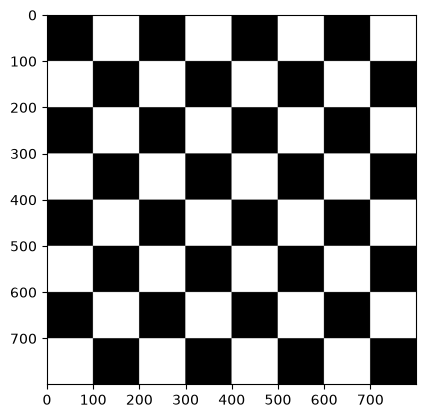

In [9]:
ancho = 800
alto = 800
gris_img = np.zeros((alto,ancho,1), dtype = np.uint8)
#Modifica un par de zonas rectangulares de la imagen
heightSlices = alto//100
widthSlices = ancho//100
count = 0
for i in range(heightSlices):
    count += 1
    for j in range(widthSlices):
            if count%2 == 0:
                gris_img[100*i:100*i +100,100*j:100*j +100] = 255
            else:
                gris_img[100*i:100*i +100,100*j:100*j +100] = 0
            count += 1

#matplotlib aplica normalización entre lso valores máximo y mínimo de la imagen
#gris_img[:,:,:] = 255 #se verá negra a menos que se especifiquen vmin y vmax

#Muestra la imagen con matplotlib
#Al ser un plano, al visualizar, recordar especificar que el mapa de color usado es de grises
plt.imshow(gris_img, cmap='gray') #Prueba sin especificar el mapa de color
#plt.imshow(gris_img, cmap='gray',vmin=0, vmax=255) #evita el efecto de la normalización de matplotlib
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

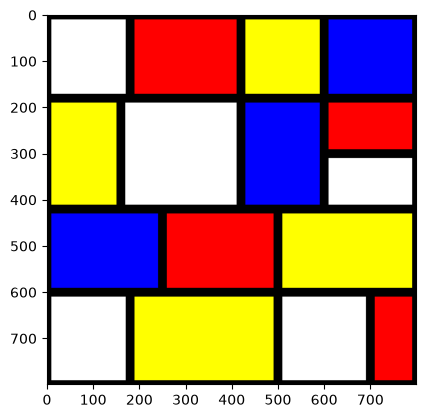

True

In [10]:
#crea una imagen con tres planos

color_img = np.zeros((alto,ancho,3), dtype = np.uint8)

#fila superior
cv2.rectangle(color_img,(10,10),(170,170),(255,255,255),-1)

cv2.rectangle(color_img,(190,10),(410,170),(0,0,255),-1)

cv2.rectangle(color_img,(430,10),(590,170),(0,255,255),-1)

cv2.rectangle(color_img,(610,10),(ancho-10,170),(255,0,0),-1)


#zona central izquierda
cv2.rectangle(color_img,(10,190),(150,410),(0,255,255),-1)

cv2.rectangle(color_img,(170,190),(410,410),(255,255,255),-1)


#zona central
cv2.rectangle(color_img,(430,190),(590,410),(255,0,0),-1)

cv2.rectangle(color_img,(610,190),(ancho-10,290),(0,0,255),-1)

cv2.rectangle(color_img,(610,310),(ancho-10,410),(255,255,255),-1)


#parte inferior izquierda
cv2.rectangle(color_img,(10,430),(240,590),(255,0,0),-1)

cv2.rectangle(color_img,(260,430),(490,590),(0,0,255),-1)

cv2.rectangle(color_img,(510,430),(ancho-10,590),(0,255,255),-1)


#parte inferior
cv2.rectangle(color_img,(10,610),(170,alto-10),(255,255,255),-1)

cv2.rectangle(color_img,(190,610),(490,alto-10),(0,255,255),-1)

cv2.rectangle(color_img,(510,610),(690,alto-10),(255,255,255),-1)

cv2.rectangle(color_img,(710,610),(ancho-10,alto-10),(0,0,255),-1)


#visualiza la imagen

plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))

plt.show()


#guarda la imagen

cv2.imwrite('imagen.jpg', color_img)

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [11]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret: 
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) #Se transforma el color del fotograma a gris
        _, _, min_loc, max_loc = cv2.minMaxLoc(gris) #Se hallan los pixeles con mayor y nenor valor
        cv2.circle(frame, min_loc, 6, (255, 0, 0), 3) #Se dibuja un círculo rojo sobre el píxel más claro
        cv2.circle(frame, max_loc, 6, (0, 0, 255), 3) #Se dibuja un círculo azul sobre el píxel más ocuro
        cv2.imshow('Cam', frame) #Se muestra el frame con el color original y los círculos
        
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

(471, 651, 3)


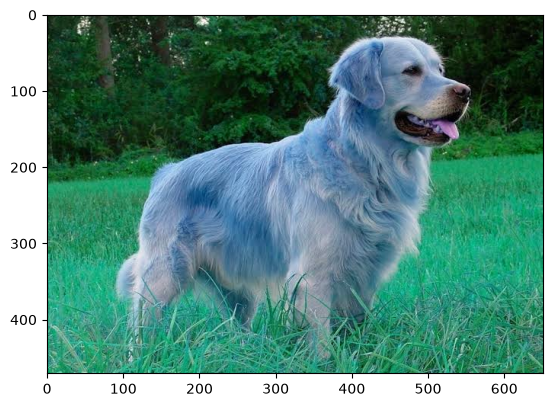

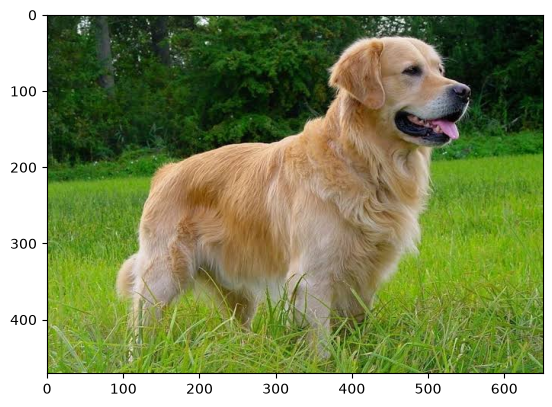

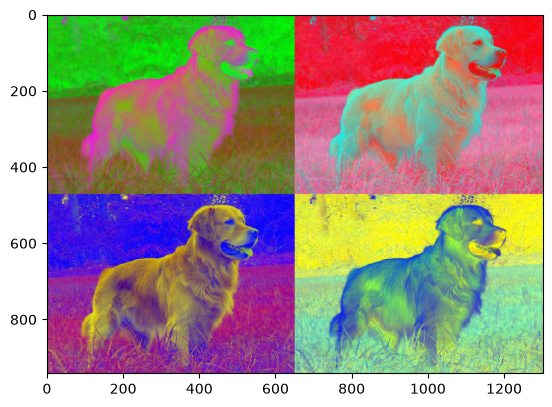

In [12]:
#carga imagen desde disco

img = cv2.imread('images.jpg')

#dimensiones

print(img.shape)

#muestra

plt.imshow(img)

plt.show()

#opencv lee las imágenes de disco en formato bgr, por lo que convertimos para visualizar rgb

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)

plt.show()


#separamos los tres canales de la imagen

r = img_rgb[:,:,0]
g = img_rgb[:,:,1]
b = img_rgb[:,:,2]


#creamos cuatro copias de la imagen

img1 = img_rgb.copy()
img2 = img_rgb.copy()
img3 = img_rgb.copy()
img4 = img_rgb.copy()


#primera imagen

img1[:,:,0] = r
img1[:,:,1] = 255 - g
img1[:,:,2] = b


#segunda imagen

img2[:,:,0] = 255 - b
img2[:,:,1] = r
img2[:,:,2] = g


#tercera imagen

img3[:,:,0] = g
img3[:,:,1] = b
img3[:,:,2] = 255 - r


#cuarta imagen

img4[:,:,0] = 255 - r
img4[:,:,1] = 255 - b
img4[:,:,2] = g


#juntamos las imagenes horizontalmente

fila1 = np.hstack((img1,img2))
fila2 = np.hstack((img3,img4))


#juntamos las dos filas

pop_art = np.vstack((fila1,fila2))


#muestra la imagen final

plt.imshow(pop_art)

plt.show()